# Building a Basic Feed Forward Neural Network Classifier in PyTorch
Neural networks are a fundamental part of deep learning. In this lesson, we will learn how to build a basic feed forward neural network classifier using PyTorch, a popular deep learning library in Python.


## Group Discussion Question

What is the difference between Keras and PyTorch? Why would I opt to use either?


## Example: Building a Feed Forward Neural Network Classifier
We will use the PyTorch library to build a simple feed forward neural network classifier. We will use the popular Iris dataset for this example.

### Step 1: Importing Libraries and Dataset
We will start by importing the necessary libraries and loading the dataset.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

### Step 2: Building the Neural Network
We will define a simple feed forward neural network with an input layer, one hidden layer, and an output layer.


In [2]:
# Define the neural network architecture
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 10)
        self.fc2 = nn.Linear(10, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model, loss function, and optimizer
model = NeuralNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Print the model summary
print(model)

NeuralNet(
  (fc1): Linear(in_features=4, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)


### Step 3: Training the Neural Network
We will train the neural network using the training data.


In [3]:
# Train the model
num_epochs = 50
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Calculate training accuracy
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_train).float().mean()
    train_accuracies.append(accuracy.item())
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        loss = criterion(outputs, y_test)
        test_losses.append(loss.item())
        
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test).float().mean()
        test_accuracies.append(accuracy.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]*100:.2f}%, Test Accuracy: {test_accuracies[-1]*100:.2f}%')

Epoch [10/50], Train Loss: 1.0721, Test Loss: 1.0467, Train Accuracy: 35.83%, Test Accuracy: 36.67%
Epoch [20/50], Train Loss: 1.0426, Test Loss: 1.0194, Train Accuracy: 45.00%, Test Accuracy: 53.33%
Epoch [30/50], Train Loss: 1.0125, Test Loss: 0.9919, Train Accuracy: 65.83%, Test Accuracy: 60.00%
Epoch [40/50], Train Loss: 0.9816, Test Loss: 0.9631, Train Accuracy: 71.67%, Test Accuracy: 70.00%
Epoch [50/50], Train Loss: 0.9497, Test Loss: 0.9327, Train Accuracy: 71.67%, Test Accuracy: 80.00%


### Step 4: Evaluating the Neural Network
We will evaluate the neural network using the testing data and plot the training history.


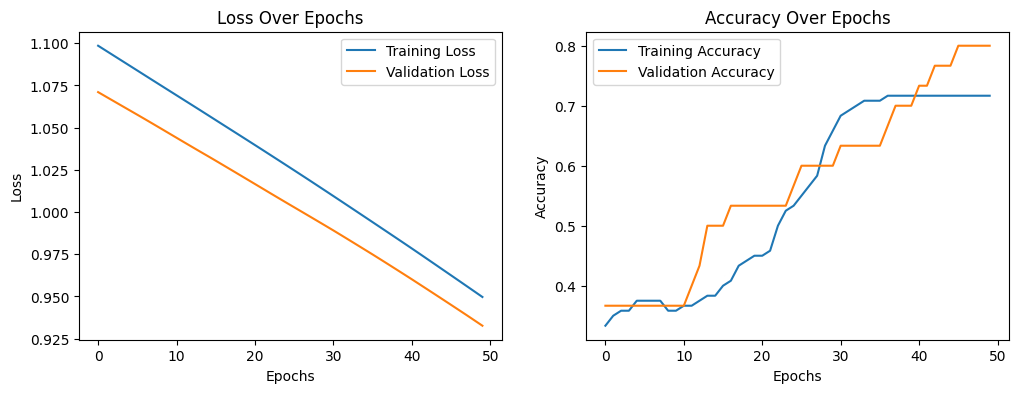

In [4]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.show()

## Practice Problems
1. Modify the neural network to include an additional hidden layer. Train and evaluate the model and compare the performance with the original model.

2. Experiment with different activation functions (e.g., sigmoid, tanh) for the hidden layer. Train and evaluate the model to see how the choice of activation function affects performance.

3. Use a different dataset (e.g., digits dataset from sklearn) and build a feed forward neural network classifier. Train and evaluate the model on the new dataset.


## Extensions and Examples

### Regularization Techniques
Explore how regularization techniques like dropout and L2 regularization can be applied to the neural network to prevent overfitting.

### Optimizers
Experiment with different optimizers (e.g., SGD, RMSprop) and compare their impact on the model's performance.

### Hyperparameter Tuning
Use hyperparameter tuning techniques such as grid search or random search to find the best set of hyperparameters for the neural network.


# Conclusion
Building a feed forward neural network classifier using PyTorch is straightforward and powerful for classification tasks. 

By understanding the basics of neural network architecture, activation functions, and model training, you can create and evaluate your own models. Experimenting with different configurations and techniques can further enhance the performance of your neural networks.
